In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_csv("cleaned_retail_sales.csv")

# Convert transaction_date back to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Check the data
df.head()



,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,...,sales_amount,payment_method,sales_channel,region,year,month,month_name,quarter,day,day_name
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,...,501.65,Debit Card,Online,North,2024,4,April,2,24,Wednesday
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,...,366.16,Credit Card,Online,South,2025,7,July,3,12,Saturday
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,...,27.99,Gift Card,In-Store,South,2025,6,June,2,1,Sunday
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,...,173.42,Cash,In-Store,South,2025,8,August,3,26,Tuesday
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,...,259.55,Cash,In-Store,Central,2024,12,December,4,10,Tuesday


In [ ]:
#Create Cohort Month
# First purchase date of each customer
df['CohortMonth'] = df.groupby('customer_id')['transaction_date'].transform('min')

# Convert to monthly period
df['CohortMonth'] = df['CohortMonth'].dt.to_period('M')

# Purchase month
df['TransactionMonth'] = df['transaction_date'].dt.to_period('M')

# Check the result
df[['customer_id', 'transaction_date', 'CohortMonth', 'TransactionMonth']].head(10)

,customer_id,transaction_date,CohortMonth,TransactionMonth
0,C000820,2024-04-24,2024-04,2024-04
1,C002849,2025-07-12,2024-01,2025-07
2,C019727,2025-06-01,2024-03,2025-06
3,C009116,2025-08-26,2024-06,2025-08
4,C003350,2024-12-10,2024-06,2024-12
5,C023912,2024-02-14,2024-02,2024-02
6,C020268,2025-10-05,2024-09,2025-10
7,C002615,2024-10-23,2024-06,2024-10
8,C011642,2025-01-14,2024-02,2025-01
9,C005355,2024-09-07,2024-06,2024-09


In [7]:
def cohort_index(transaction_month, cohort_month):
    return (
        (transaction_month.year - cohort_month.year) * 12
        + (transaction_month.month - cohort_month.month)
        + 1
    )

df['CohortIndex'] = df.apply(
    lambda row: cohort_index(row['TransactionMonth'], row['CohortMonth']),
    axis=1
)

df[['customer_id', 'CohortMonth', 'TransactionMonth', 'CohortIndex']].head(10)

,customer_id,CohortMonth,TransactionMonth,CohortIndex
0,C000820,2024-04,2024-04,1
1,C002849,2024-01,2025-07,19
2,C019727,2024-03,2025-06,16
3,C009116,2024-06,2025-08,15
4,C003350,2024-06,2024-12,7
5,C023912,2024-02,2024-02,1
6,C020268,2024-09,2025-10,14
7,C002615,2024-06,2024-10,5
8,C011642,2024-02,2025-01,12
9,C005355,2024-06,2024-09,4


In [8]:
def cohort_index(transaction_month, cohort_month):
    return (
        (transaction_month.year - cohort_month.year) * 12
        + (transaction_month.month - cohort_month.month)
        + 1
    )

df['CohortIndex'] = df.apply(
    lambda row: cohort_index(row['TransactionMonth'], row['CohortMonth']),
    axis=1
)

df[['customer_id', 'CohortMonth', 'TransactionMonth', 'CohortIndex']].head(10)

,customer_id,CohortMonth,TransactionMonth,CohortIndex
0,C000820,2024-04,2024-04,1
1,C002849,2024-01,2025-07,19
2,C019727,2024-03,2025-06,16
3,C009116,2024-06,2025-08,15
4,C003350,2024-06,2024-12,7
5,C023912,2024-02,2024-02,1
6,C020268,2024-09,2025-10,14
7,C002615,2024-06,2024-10,5
8,C011642,2024-02,2025-01,12
9,C005355,2024-06,2024-09,4


In [9]:
df[['customer_id', 'CohortMonth', 'TransactionMonth', 'CohortIndex']].sample(10)

,customer_id,CohortMonth,TransactionMonth,CohortIndex
119612,C003519,2024-05,2025-06,14
49784,C007084,2024-01,2025-12,24
65477,C019674,2024-04,2025-03,12
94215,C021024,2024-12,2025-06,7
44562,C015548,2024-12,2024-12,1
62583,C009748,2024-03,2025-05,15
69422,C021196,2024-03,2025-09,19
104577,C006817,2025-02,2025-02,1
75897,C004208,2025-02,2025-02,1
36855,C024904,2024-03,2025-02,12


In [10]:
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['customer_id'].nunique().reset_index()

cohort_data.head()

,CohortMonth,CohortIndex,customer_id
0,2024-01,1,4614
1,2024-01,2,757
2,2024-01,3,822
3,2024-01,4,827
4,2024-01,5,850


In [15]:
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['customer_id'].nunique().reset_index()

In [17]:
cohort_counts = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='customer_id'
)

In [18]:
cohort_size = cohort_counts.iloc[:, 0]

retention = cohort_counts.divide(cohort_size, axis=0)

retention.head()

CohortIndex,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2024-01,1.0,0.164066,0.178153,0.179237,0.184222,0.175336,0.183138,0.179020,0.180971,0.184222,...,0.180971,0.177070,0.181838,0.178804,0.190074,0.186173,0.177070,0.185089,0.171001,0.182922
2024-02,1.0,0.181363,0.176912,0.199166,0.183310,0.177191,0.177747,0.174965,0.180250,0.189430,...,0.176356,0.194159,0.177191,0.190264,0.188595,0.187204,0.194715,0.177191,0.194437,NaN
2024-03,1.0,0.180916,0.178674,0.175793,0.178354,0.182517,0.187640,0.182837,0.170669,0.189882,...,0.172270,0.181236,0.198847,0.174191,0.173551,0.185399,0.176753,0.176113,NaN,NaN
2024-04,1.0,0.184976,0.186591,0.180937,0.192649,0.174475,0.168013,0.175283,0.177706,0.187399,...,0.191842,0.184976,0.175283,0.173263,0.195477,0.187803,0.187803,NaN,NaN,NaN
2024-05,1.0,0.174203,0.177059,0.173727,0.189434,0.188006,0.174679,0.193717,0.188006,0.164683,...,0.187054,0.202285,0.177535,0.182770,0.180390,0.183722,NaN,NaN,NaN,NaN


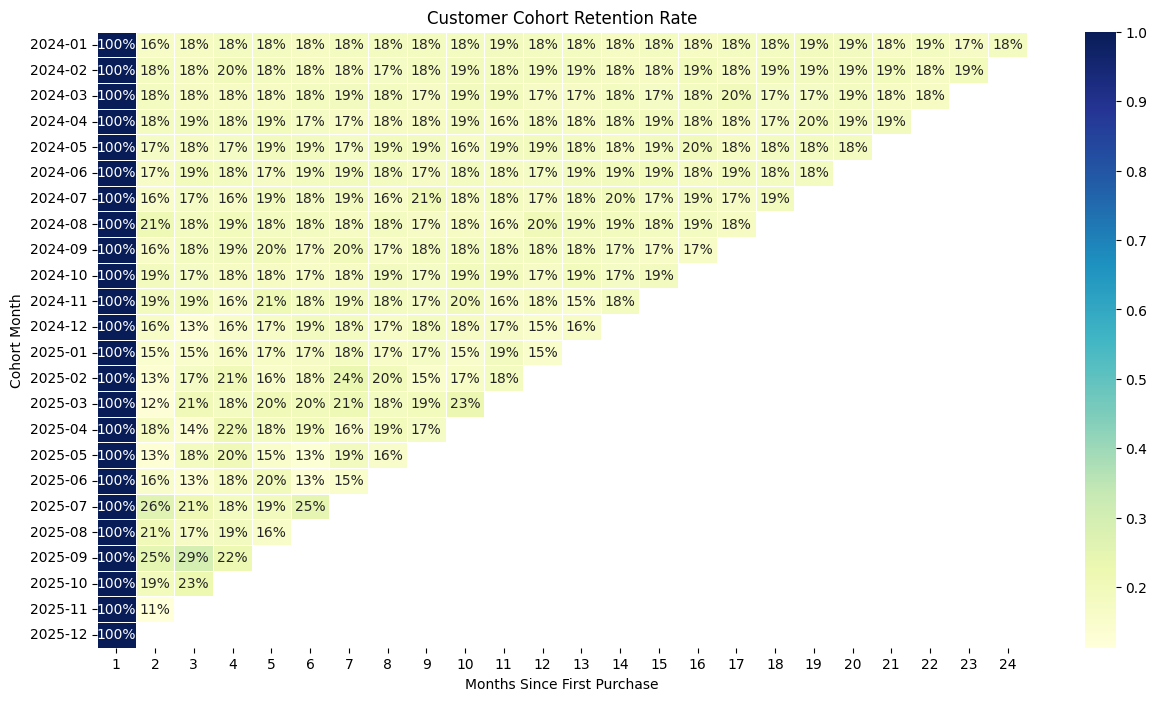

In [19]:
plt.figure(figsize=(15,8))

sns.heatmap(
    retention,
    annot=True,
    fmt=".0%",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Customer Cohort Retention Rate")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.show()

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/cleaned_retail_sales.csv")

df["transaction_date"] = pd.to_datetime(df["transaction_date"])

In [ ]:
#Find each customer's first purchase date
df["Cohort_Date"] = df.groupby("customer_id")["transaction_date"].transform("min")

df[["customer_id", "transaction_date", "Cohort_Date"]].head()

,customer_id,transaction_date,Cohort_Date
0,C000820,2024-04-24,2024-04-24
1,C002849,2025-07-12,2024-01-04
2,C019727,2025-06-01,2024-03-25
3,C009116,2025-08-26,2024-06-11
4,C003350,2024-12-10,2024-06-05


In [ ]:
#Create Cohort Month
df["Cohort_Month"] = df["Cohort_Date"].dt.to_period("M")
df["Transaction_Month"] = df["transaction_date"].dt.to_period("M")

In [33]:
#Calculate Cohort Index
df["Cohort_Index"] = (
    (df["Transaction_Month"].dt.year - df["Cohort_Month"].dt.year) * 12
    + (df["Transaction_Month"].dt.month - df["Cohort_Month"].dt.month)
)

In [ ]:
#Build the Cohort Table
cohort_data = (
    df.groupby(["Cohort_Month", "Cohort_Index"])["customer_id"]
      .nunique()
      .reset_index()
)

cohort_data.head()

,Cohort_Month,Cohort_Index,customer_id
0,2024-01,0,4614
1,2024-01,1,757
2,2024-01,2,822
3,2024-01,3,827
4,2024-01,4,850


In [ ]:
#Create the Cohort Matrix
cohort_matrix = cohort_data.pivot(
    index="Cohort_Month",
    columns="Cohort_Index",
    values="customer_id"
)

cohort_matrix

Cohort_Index,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Cohort_Month,,,,,,,,,,,,,,,,,,,,,
2024-01,4614.0,757.0,822.0,827.0,850.0,809.0,845.0,826.0,835.0,850.0,...,835.0,817.0,839.0,825.0,877.0,859.0,817.0,854.0,789.0,844.0
2024-02,3595.0,652.0,636.0,716.0,659.0,637.0,639.0,629.0,648.0,681.0,...,634.0,698.0,637.0,684.0,678.0,673.0,700.0,637.0,699.0,NaN
2024-03,3123.0,565.0,558.0,549.0,557.0,570.0,586.0,571.0,533.0,593.0,...,538.0,566.0,621.0,544.0,542.0,579.0,552.0,550.0,NaN,NaN
2024-04,2476.0,458.0,462.0,448.0,477.0,432.0,416.0,434.0,440.0,464.0,...,475.0,458.0,434.0,429.0,484.0,465.0,465.0,NaN,NaN,NaN
2024-05,2101.0,366.0,372.0,365.0,398.0,395.0,367.0,407.0,395.0,346.0,...,393.0,425.0,373.0,384.0,379.0,386.0,NaN,NaN,NaN,NaN
2024-06,1681.0,282.0,326.0,303.0,283.0,312.0,320.0,305.0,288.0,302.0,...,325.0,300.0,321.0,302.0,306.0,NaN,NaN,NaN,NaN,NaN
2024-07,1376.0,221.0,237.0,227.0,265.0,241.0,258.0,223.0,287.0,243.0,...,240.0,260.0,235.0,261.0,NaN,NaN,NaN,NaN,NaN,NaN
2024-08,1111.0,235.0,202.0,214.0,204.0,204.0,195.0,205.0,189.0,197.0,...,203.0,206.0,196.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09,844.0,138.0,154.0,158.0,166.0,143.0,169.0,140.0,155.0,154.0,...,142.0,142.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Calculate Retention %
retention_matrix = cohort_matrix.divide(cohort_matrix[0], axis=0) * 100

retention_matrix.round(2)

Cohort_Index,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Cohort_Month,,,,,,,,,,,,,,,,,,,,,
2024-01,100.0,16.41,17.82,17.92,18.42,17.53,18.31,17.90,18.10,18.42,...,18.10,17.71,18.18,17.88,19.01,18.62,17.71,18.51,17.10,18.29
2024-02,100.0,18.14,17.69,19.92,18.33,17.72,17.77,17.50,18.03,18.94,...,17.64,19.42,17.72,19.03,18.86,18.72,19.47,17.72,19.44,NaN
2024-03,100.0,18.09,17.87,17.58,17.84,18.25,18.76,18.28,17.07,18.99,...,17.23,18.12,19.88,17.42,17.36,18.54,17.68,17.61,NaN,NaN
2024-04,100.0,18.50,18.66,18.09,19.26,17.45,16.80,17.53,17.77,18.74,...,19.18,18.50,17.53,17.33,19.55,18.78,18.78,NaN,NaN,NaN
2024-05,100.0,17.42,17.71,17.37,18.94,18.80,17.47,19.37,18.80,16.47,...,18.71,20.23,17.75,18.28,18.04,18.37,NaN,NaN,NaN,NaN
2024-06,100.0,16.78,19.39,18.02,16.84,18.56,19.04,18.14,17.13,17.97,...,19.33,17.85,19.10,17.97,18.20,NaN,NaN,NaN,NaN,NaN
2024-07,100.0,16.06,17.22,16.50,19.26,17.51,18.75,16.21,20.86,17.66,...,17.44,18.90,17.08,18.97,NaN,NaN,NaN,NaN,NaN,NaN
2024-08,100.0,21.15,18.18,19.26,18.36,18.36,17.55,18.45,17.01,17.73,...,18.27,18.54,17.64,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09,100.0,16.35,18.25,18.72,19.67,16.94,20.02,16.59,18.36,18.25,...,16.82,16.82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Calculate Retention 
cohort_matrix.to_csv("data/cohort_matrix.csv")
retention_matrix.to_csv("data/retention_matrix.csv")